### **Auto Insurance - Vehicle Crash Prediction**

#### **Dataset**
- The dataset is related to automobile insurance and contains information on 8161 individuals and their insurance and insurance policy choices.
- It includes 26 variables such as demographic information, car-related information, and prior insurance history.
- The target variable is "TARGET_FLAG", which indicates whether an individual was involved in a car crash (1) or not (0).

The goal is to build a statistical model that accurately predicts the likelihood of a customer having a car crash, based on their demographic and vehicle-related information provided in the dataset.

#### Data loading and exploration

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import LabelEncoder 
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import statsmodels.api as sm 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings 
warnings.filterwarnings('ignore')

In [ ]:
# Loading data from csv file 
fileName = ""
df = pd.read_csv(filepath_or_buffer=fileName)


-----------------------------------------------------------

Interpretable Machine Learning


Model Based: Build interpretable. 

Post-hoc: derive explanations for complex ML models. 


---- Categorization in xAI: <br> 
++ Agnosticity <br>
- Model-agnostic: applicable to all model types. <br>
- Model-specific specific to certain models. <br>


++ Scope
- Global explanation: explaining the whole model<br>
- Local explanation:  explaining parts of the model (for instance, individual predictions)<br>

++ Data type
- Graph
- Text/speech
- Image
- Tabular

++ Explanation type
- Visual (correlation plots)
- Feature importance (feature summaries)
- Data points (return data points to understand the models)
- Surrogate models (build simpler models around complex ones)

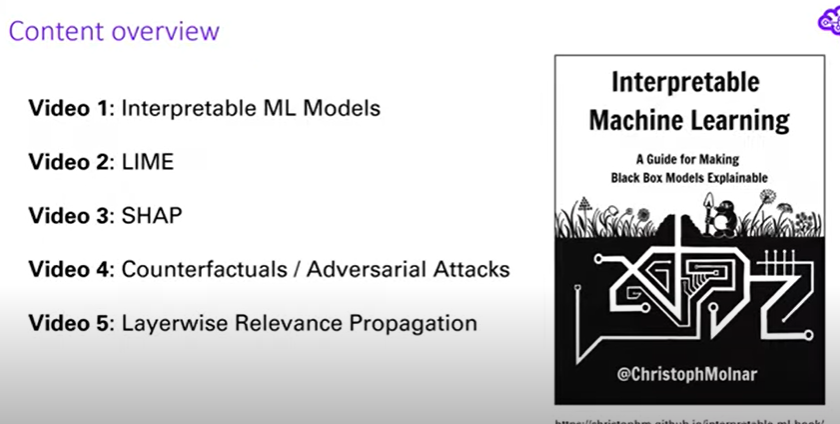

-- Causual reasoning: high degree of interpretability

##### Part 2: By-design intepretable models with Microsoft InterpretML

+ Glass-Box models
- Decision Tree 
- Logistic Regression
- Explanable Boosting Machine (developed by Microsoft)

In [33]:
import matplotlib.pyplot as plt 
from utils import DataLoader

In [58]:
# Load data 
data_loader = DataLoader()
data_loader.load_dataset()
data = data_loader.data

In [59]:
# Show head
print(data.shape)
data.head()

(5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [60]:
# Show general stats
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


col: id


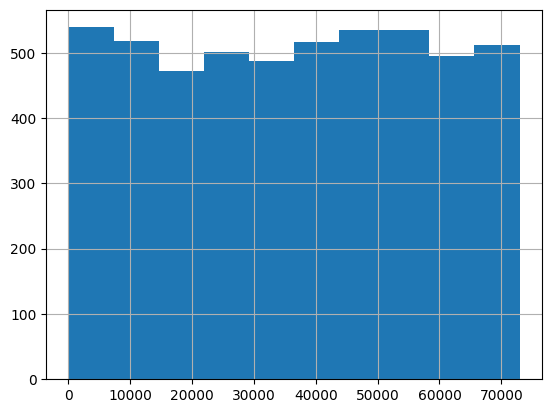

col: gender


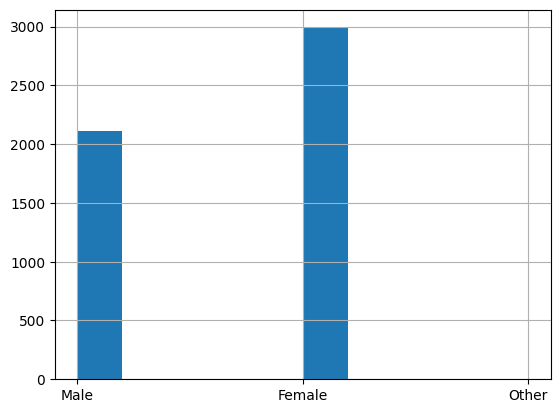

col: age


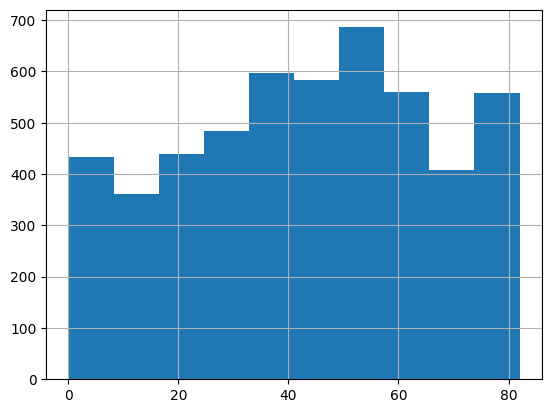

col: hypertension


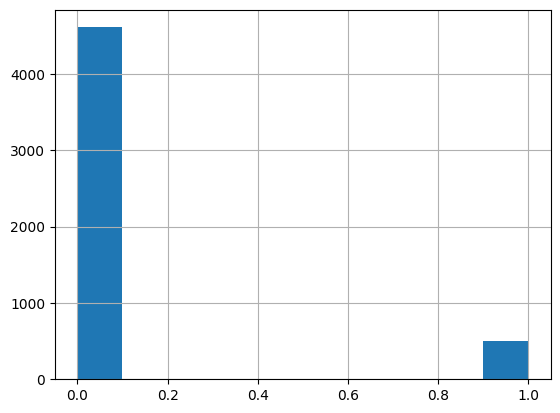

col: heart_disease


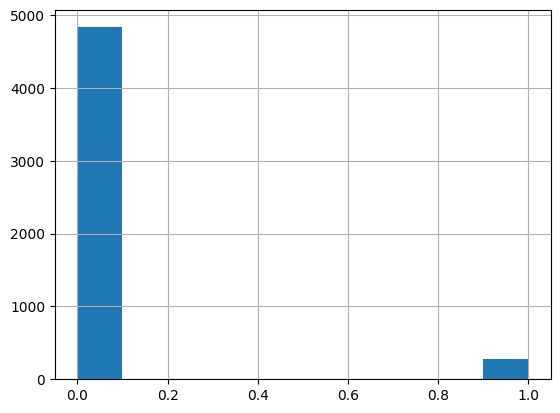

col: ever_married


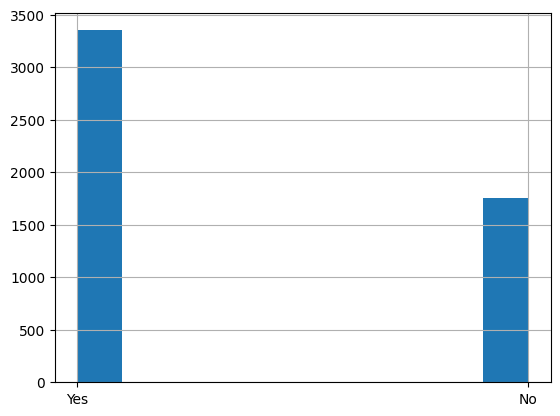

col: work_type


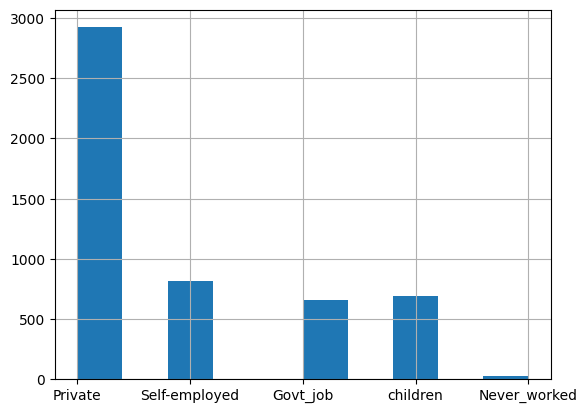

col: Residence_type


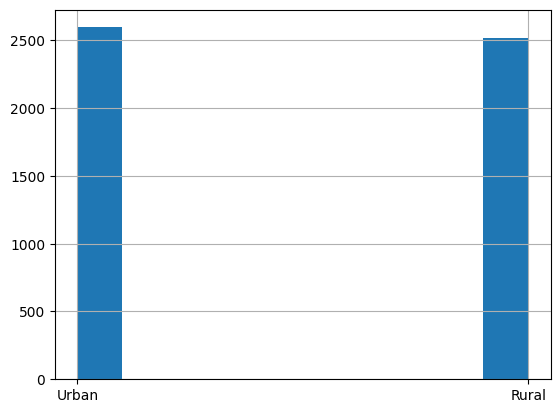

col: avg_glucose_level


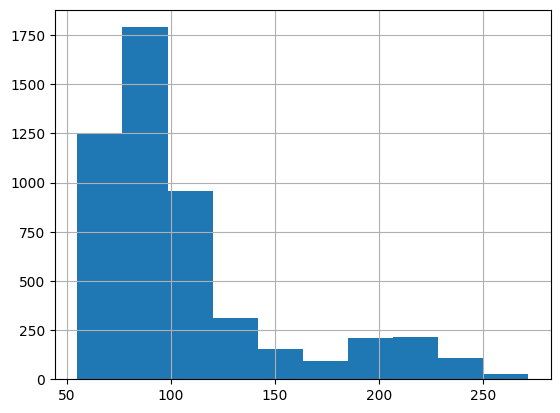

col: bmi


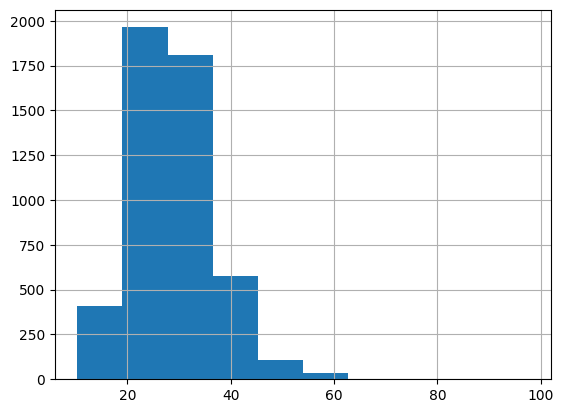

col: smoking_status


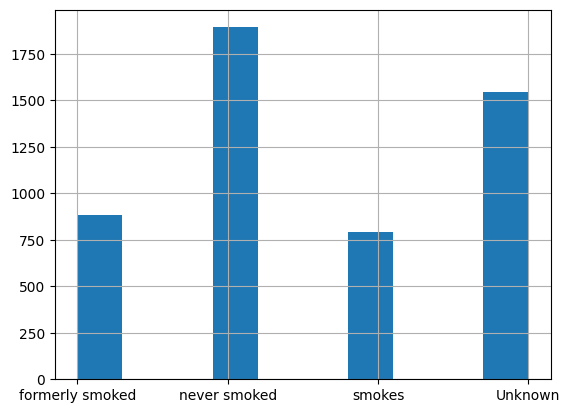

col: stroke


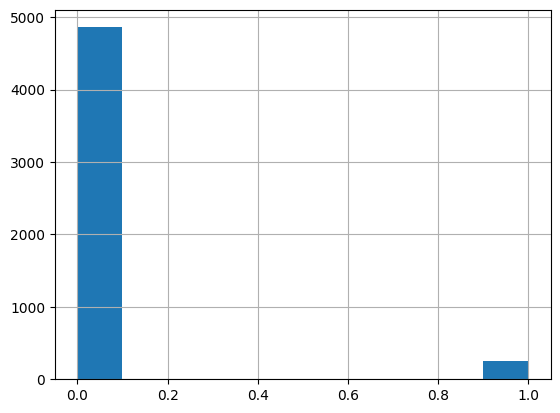

In [13]:
# Show histogram for all columns
columns = data.columns
for col in columns:
    print(f"col: {col}")
    data[col].hist()
    plt.show()

In [61]:
data_loader.preprocess_data()
data_loader.data.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,gender_Other,ever_married_No,ever_married_Yes,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,1,False,True,False,False,True,False,False,True,False,False,False,True,False,True,False,False
1,61.0,0,0,202.21,0.0,1,True,False,False,False,True,False,False,False,True,False,True,False,False,False,True,False
2,80.0,0,1,105.92,32.5,1,False,True,False,False,True,False,False,True,False,False,True,False,False,False,True,False
3,49.0,0,0,171.23,34.4,1,True,False,False,False,True,False,False,True,False,False,False,True,False,False,False,True
4,79.0,1,0,174.12,24.0,1,True,False,False,False,True,False,False,False,True,False,True,False,False,False,True,False


In [39]:
# %% Imports
from utils import DataLoader
from interpret.glassbox import (LogisticRegression,
                                ClassificationTree, 
                                ExplainableBoostingClassifier)
from interpret import show
from sklearn.metrics import f1_score, accuracy_score


In [40]:
# %% Load and preprocess data
data_loader = DataLoader()
data_loader.load_dataset()
data_loader.preprocess_data()


In [50]:
data_loader.data.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,gender_Other,ever_married_No,ever_married_Yes,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,1,False,True,False,False,True,False,False,True,False,False,False,True,False,True,False,False
1,61.0,0,0,202.21,0.0,1,True,False,False,False,True,False,False,False,True,False,True,False,False,False,True,False
2,80.0,0,1,105.92,32.5,1,False,True,False,False,True,False,False,True,False,False,True,False,False,False,True,False
3,49.0,0,0,171.23,34.4,1,True,False,False,False,True,False,False,True,False,False,False,True,False,False,False,True
4,79.0,1,0,174.12,24.0,1,True,False,False,False,True,False,False,False,True,False,True,False,False,False,True,False


In [56]:
# Split the data for evaluation
X_train, X_test, y_train, y_test = data_loader.get_data_split()
print(X_train.shape)
print(X_test.shape)

(4088, 21)
(1022, 21)


In [63]:
# Oversample the train data
X_train, y_train = data_loader.oversample(X_train, y_train)

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/home/sething2002/.local/lib/python3.10/site-packages/IPython/core/interactiveshell.py", line 3508, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_252003/1933691019.py", line 2, in <module>
    X_train, y_train = data_loader.oversample(X_train, y_train)
  File "/home/sething2002/2024_UoA/s2/COMP_SCI_3006_SEP_Project/xAI/utils.py", line 53, in oversample
    oversampler = RandomOverSampler(sampling_strategy="minority")
TypeError: 'RandomOverSampler' object is not callable

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/sething2002/.local/lib/python3.10/site-packages/IPython/core/interactiveshell.py", line 2105, in showtraceback
    stb = self.InteractiveTB.structured_traceback(
  File "/home/sething2002/.local/lib/python3.10/site-packages/IPython/core/ultratb.py", line 1428, in structured_traceback
    return FormattedTB.structured_t

In [ ]:
# https://xai-tutorials.readthedocs.io/en/latest/_model_agnostic_xai/pfi.html

In [43]:

print("After oversampling:", X_train.shape)

After oversampling: (4088, 21)
